In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'https://raw.githubusercontent.com/avnyadav/sensor-fault-detection/main/aps_failure_training_set1.csv',na_values="na")

In [3]:
df

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,1.820000e+02,NaN,0.0,0.0,0.0,0.0,0.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2.926000e+03,NaN,0.0,0.0,0.0,0.0,222.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1.594000e+03,1052.0,0.0,0.0,0.0,244.0,178226.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
3,pos,762958,NaN,NaN,NaN,NaN,NaN,776.0,281128.0,2186308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pos,695994,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,1397742.0,495544.0,361646.0,28610.0,5130.0,212.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36183,neg,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
36184,neg,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
36185,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
36186,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


In [4]:
# !pip install xgboost

In [5]:
# !pip install catboost

In [6]:
#sys.executable         #get path upto virtual env
import sys
print(sys.executable)   #but here a problem, space between
# (Data Science Project) so sys.executable only take
# upto (Data) path, to solve this problem i used double quotes
#  !"{sys.executable}"  to install any library                   

c:\Users\PAK\Data Science Projects\livesensor\chick\Scripts\python.exe


In [7]:
import os
os.getcwd()  #get path upto project_run only... if i 
#want to install anything(library) in my venv(chick), so 
#i need to get the path upto venv(chick)

'c:\\Users\\PAK\\Data Science Projects\\livesensor'

In [8]:

#!"{sys.executable}" -m pip install seaborn 
# %pip work but !pip fail
# %pip install seaborn     #restart kernel



In [9]:
# %pip install scikit-learn

In [10]:
import seaborn as sns
from statistics import mean
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix


from sklearn import metrics
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold,cross_val_score

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
%matplotlib inline


In [11]:
#python.exe -m pip install --upgrade pip
#  %pip install --upgrade pip

In [12]:
df['class'].value_counts()

class
neg    35188
pos     1000
Name: count, dtype: int64

In [13]:
df.head()


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,0.0,182.0,NaN,0.0,0.0,0.0,0.0,0.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,NaN,2926.0,NaN,0.0,0.0,0.0,0.0,222.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,NaN,1594.0,1052.0,0.0,0.0,0.0,244.0,178226.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
3,pos,762958,NaN,NaN,NaN,NaN,NaN,776.0,281128.0,2186308.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,pos,695994,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,1397742.0,495544.0,361646.0,28610.0,5130.0,212.0,0.0,0.0,NaN,NaN


This is a List Comprehension

[expression for item in iterable if condition]

In [14]:
#[expression for item in iterable if condition]

In [15]:
#O means object(string)  not zero

numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']

#Alternative
# numerical_features = []      create an empty list

# for feature in df.columns:     Go_through each column name, give output in vertical but i want in list
#     if df[feature].dtype != 'O':   check the cols datatype
#         numerical_features.append(feature) 
#                       add numeric cols in the list


#add multiple line comment use keyboard shortcut  ctrl+/

How many cols are Numerical  and Categorical

In [16]:
print(f"we have {len(numerical_features)} features: {numerical_features}")
print(f"We have {len(categorical_feature)} features: {categorical_feature}")


we have 170 features: ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'ci_000', 'cj_000', 'ck_000', 'cl_000',

In [17]:
df.isnull().sum().to_frame().sort_values(by=0,ascending=False)

,0
br_000,29461
bq_000,29132
bp_000,28514
ab_000,27896
cr_000,27896
...,...
cj_000,203
ci_000,203
bt_000,86
aa_000,0


In [18]:
df.shape

(36188, 171)

In [19]:
df.shape[1]


171

Check missing values using Barplot

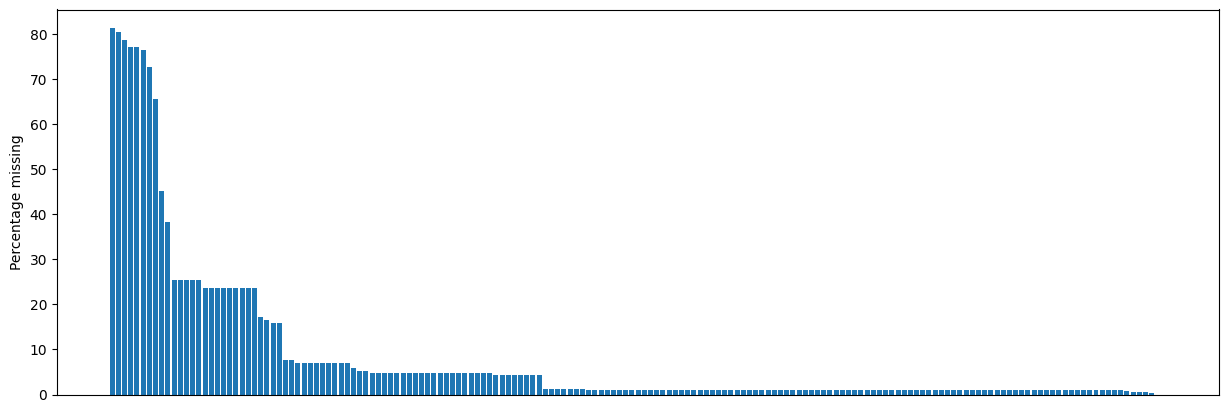

In [20]:
#Plotting Missing values count for each coluen

fig, ax = plt.subplots(figsize=(15,5))

#  [wrong bcz 100.to_frame()]  missing = df.isna().sum().mean()*100.to_frame().sort_values(by=0, ascending=False)
#  correct;  mean()*100    correct:  .div().mul()  not vice-versa
missing = df.isna().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)
ax.bar(missing.index, missing.values.T[0])
# ax.bar() expects:    ax.bar(x_vales, y_values)
#             x_values -> labels(index) in datafram
#             y_values -> 1D numeric_array
# but missing.values is 2D that's why transpose 2D into 1D 
# using T
#     missing   = A datafram
# missing.index = cols_name
# misisng.values = 1, 2 or more D numpy_array

plt.xticks([])

plt.ylabel("Percentage missing")

plt.show()

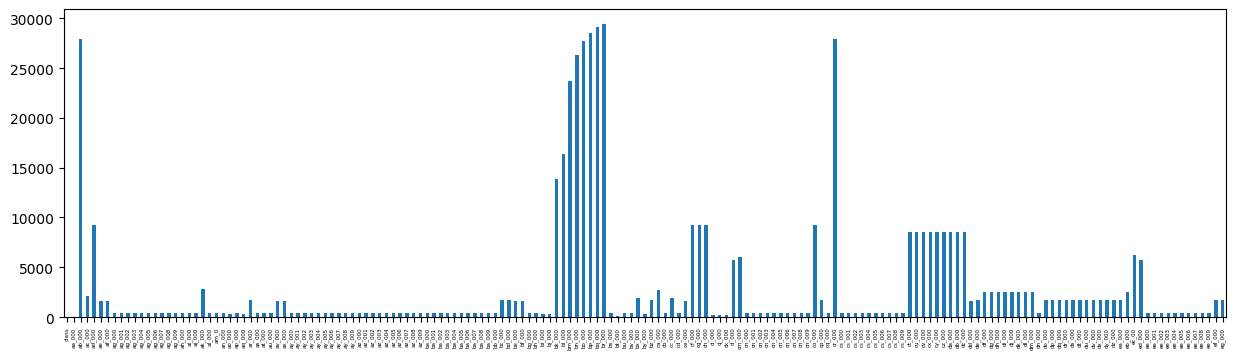

In [21]:
df.isna().sum().plot(kind='bar', figsize=(15,4))
plt.xticks(rotation=90, fontsize= 4)
plt.show()

Summary Table(Clean Report)

In [22]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
}).sort_values(by="missing_pct", ascending=False)

missing_report

,missing_count,missing_pct
br_000,29461,81.410965
bq_000,29132,80.501824
bp_000,28514,78.794075
ab_000,27896,77.086327
cr_000,27896,77.086327
...,...,...
cj_000,203,0.560959
ci_000,203,0.560959
bt_000,86,0.237648
aa_000,0,0.000000


Check missing values using Heatmap

X-axis(columns)
-> Each vertical strip is one column / feature in your dataset

Y-axis(rows)
-> Each horizontal line is one row / record

-> (You hid labels because there are many rows)

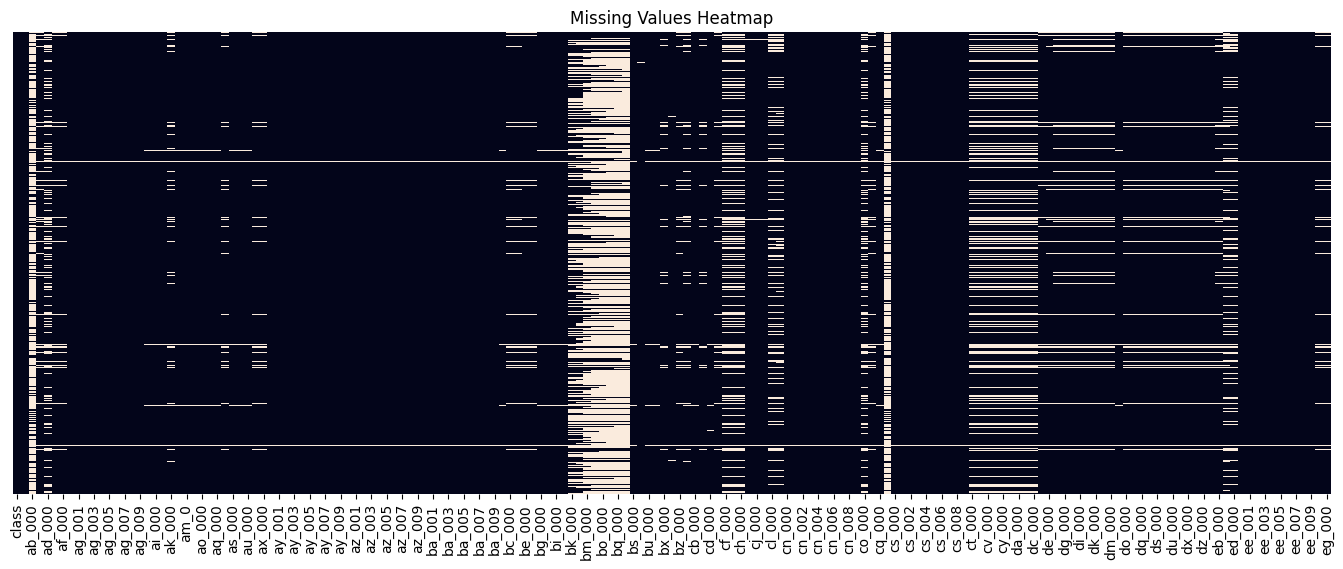

In [23]:
plt.figure(figsize=(17,6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

Dark color (almost black / blue)
→ Value is NOT missing (data is present)

Light / white color
→ Value IS missing (NaN)

In [24]:
df.tail(3)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
36185,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
36186,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0
36187,neg,40222,NaN,6.980000e+02,628.0,0.0,0.0,0.0,0.0,0.0,...,440066.0,183200.0,344546.0,254068.0,225148.0,158304.0,170384.0,158.0,0.0,0.0


Droppig Columns which has more than 70% of missing values

In [25]:
missing = df.isna().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)
missing           #missing values in percentage

,0
br_000,81.410965
bq_000,80.501824
bp_000,78.794075
ab_000,77.086327
cr_000,77.086327
...,...
cj_000,0.560959
ci_000,0.560959
bt_000,0.237648
aa_000,0.000000


In [26]:
#missing = df.isna().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0, ascending=False)
dropcols = missing[missing[0]>70]  #0 is col_name 
#check how many cols that need to drop
dropcols

,0
br_000,81.410965
bq_000,80.501824
bp_000,78.794075
ab_000,77.086327
cr_000,77.086327
bo_000,76.533658
bn_000,72.761689


In [27]:
#dropcols.index   #return list + datatype
list(dropcols.index)  #retur only list

['br_000', 'bq_000', 'bp_000', 'ab_000', 'cr_000', 'bo_000', 'bn_000']

In [28]:
df.drop(list(dropcols.index), axis=1, inplace=True)
#drop() removes specific cols or rows, by name or index
#dropna() removes cols or rows that contain Nan values


In [29]:
df.shape

(36188, 164)

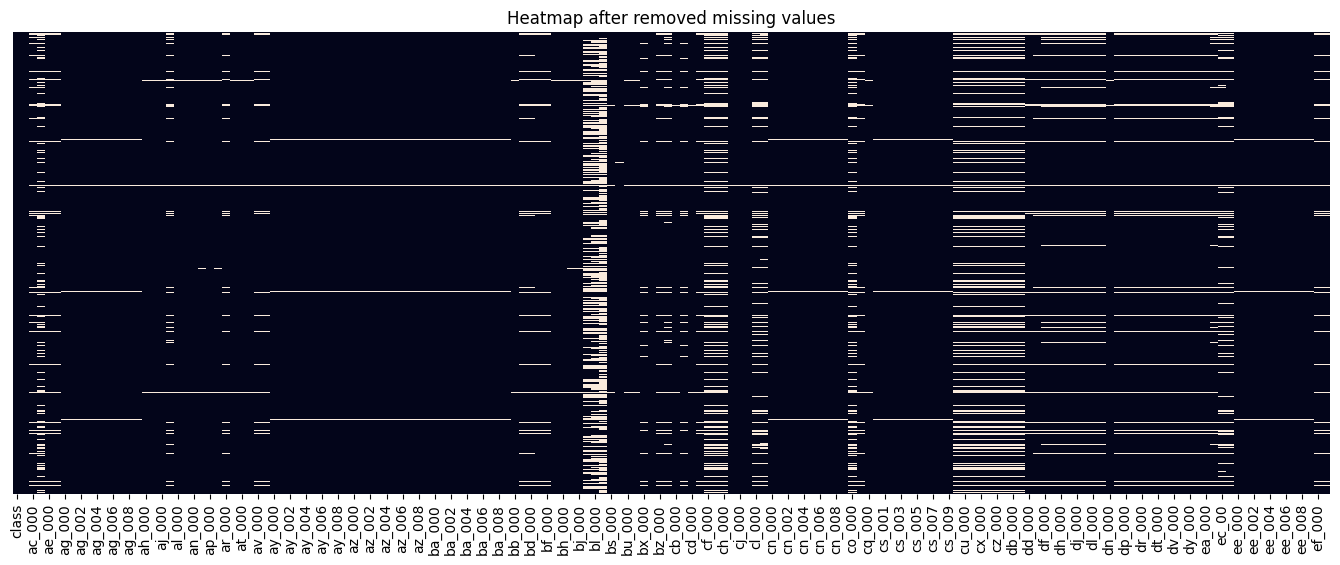

In [30]:
plt.figure(figsize=(17,6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Heatmap after removed missing values")
plt.show()

In [31]:
# wrong   df["bs_000"].isna().sum().mean()*100
#dont use sum() with mean()
df["bs_000"].isna().sum()    
#df["bs_000"].isna().mean()*100   check in %percentage

np.int64(419)

In [32]:
df["bl_000"].isna().sum()           #check in counts
#df["bl_000"].isna().mean()*100

np.int64(16335)

Visualization of Unique values in Target variable

In [33]:
df.head(3)

,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,pos,153204,182.0,NaN,0.0,0.0,0.0,0.0,0.0,11804.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0
1,pos,453236,2926.0,NaN,0.0,0.0,0.0,0.0,222.0,323436.0,...,7908038.0,3026002.0,5025350.0,2025766.0,1160638.0,533834.0,493800.0,6914.0,0.0,0.0
2,pos,72504,1594.0,1052.0,0.0,0.0,0.0,244.0,178226.0,1249396.0,...,1432098.0,372252.0,527514.0,358274.0,332818.0,284178.0,3742.0,0.0,0.0,0.0
